# 14 — Validating Our Violence Labels Against an Independent Coder

Notebook `13` showed the violence-contagion result survives *our own* missing-data choices. But there is a prior question a reviewer will ask: **are our violence labels even right?** The `power_transitions` file codes a transition as violent from four event variables (assassination, military revolt, popular uprising, external invasion). Those are our (well, CrisisDB's) codings — is there any *independent* signal that agrees?

This notebook cross-checks against a **separately-coded** CrisisDB module: **Hoyer et al. 2023/2024, "Navigating Polycrisis"** ([Dryad, CC0](https://datadryad.org/dataset/doi:10.5061/dryad.mkkwh715m)), which codes 13 crisis *consequences* — including uprising, civil war, assassination, and deposition — for 169 historical crisis cases, by a different coding effort. If our transition-level violence labels and their case-level consequence codes disagree wildly, our signal is suspect. If they line up, the contagion result rests on something more than one team's judgment.

**Honest scope up front:** the two datasets share only ~47 polities by exact name, so this is a *small-sample concordance check*, not a definitive validation. It is reported with that caveat, not hidden behind it.


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pt = pd.read_csv('power_transitions.csv', sep='|')
npc = pd.read_csv('../data_external/seshat-datasets/CrisisConsequencesData_NavigatingPolycrisis_2023.03.csv', encoding='latin-1')
print('power_transitions:', pt.shape, '| navigating-polycrisis:', npc.shape)

OUTCOME = ['uprising','civil.war','assassin','depose']  # the violence-relevant consequences
print('\nHow the independent coder records these (value counts):')
for c in OUTCOME:
    print(f'  {c:10}', dict(npc[c].value_counts(dropna=False).head(6)))


power_transitions: (3447, 23) | navigating-polycrisis: (169, 22)

How the independent coder records these (value counts):
  uprising   {'0': np.int64(83), '1': np.int64(75), 'U.susp': np.int64(9), '1.inf': np.int64(1), '0.inf': np.int64(1)}
  civil.war  {'1': np.int64(82), '0': np.int64(74), 'U.susp': np.int64(8), '1.inf': np.int64(3), '0.inf': np.int64(2)}
  assassin   {'0': np.int64(96), '1': np.int64(55), 'U.susp': np.int64(17), '0.inf': np.int64(1)}
  depose     {'0': np.int64(74), '1': np.int64(66), 'U.susp': np.int64(22), '0.inf': np.int64(5), '1.inf': np.int64(2)}


## 1. Build the two signals on the shared polities

**Our signal:** for each polity, the fraction of its power transitions coded violent (present or inferred-present, matching notebook 03).

**Their signal:** for each polity's crisis case, whether *any* of {uprising, civil war, assassination, deposition} is coded present.


In [2]:
# our per-polity violent-transition rate
VC = ['predecessor_assassination','military_revolt','popular_uprising','external_invasion']
for c in VC: pt[f'{c}_b'] = pt[c].isin(['P','IP']).astype(int)
pt['violent'] = pt[[f'{c}_b' for c in VC]].max(axis=1)
ours = pt.groupby('polity_name')['violent'].mean().rename('our_violent_rate')

# their per-polity 'any violent consequence' flag; codes use present/absent-style strings
def is_present(v):
    if pd.isna(v): return 0
    return int(str(v).strip().lower() in ('present','p','1','yes','y','inferred present','ip'))
theirs_any = (npc.set_index('Polity.Name')[OUTCOME].applymap(is_present).max(axis=1)
              .groupby(level=0).max().rename('their_any_violence'))

merged = pd.concat([ours, theirs_any], axis=1, join='inner').dropna()
print(f'Shared polities with both signals: {len(merged)}')
print(merged.describe().round(3).to_string())


Shared polities with both signals: 47
       our_violent_rate  their_any_violence
count            47.000              47.000
mean              0.437               0.894
std               0.249               0.312
min               0.000               0.000
25%               0.268               1.000
50%               0.450               1.000
75%               0.626               1.000
max               1.000               1.000


/var/folders/m4/37z2ytt50pj_m88_04m8t5wc0000gn/T/ipykernel_62451/2211627904.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  theirs_any = (npc.set_index('Polity.Name')[OUTCOME].applymap(is_present).max(axis=1)


## 2. Do they agree?

If our violence rate is a real signal, polities the independent coder flags as having a violent crisis consequence should have a *higher* mean violent-transition rate than those it doesn't.


In [3]:
flagged = merged[merged['their_any_violence']==1]['our_violent_rate']
unflag  = merged[merged['their_any_violence']==0]['our_violent_rate']
print(f'Our mean violent-transition rate:')
print(f'  polities the independent coder flags violent   (n={len(flagged)}): {flagged.mean():.1%}')
print(f'  polities it does NOT flag violent              (n={len(unflag)}): {unflag.mean():.1%}')

from scipy.stats import mannwhitneyu, pointbiserialr
if len(flagged)>2 and len(unflag)>2:
    u,p = mannwhitneyu(flagged, unflag, alternative='greater')
    r,pr = pointbiserialr(merged['their_any_violence'], merged['our_violent_rate'])
    print(f'\n  Mann-Whitney (flagged > unflagged): U={u:.0f}, p={p:.3f}')
    print(f'  point-biserial correlation:         r={r:.3f}, p={pr:.3f}')
else:
    print('\n  one group too small for a test — reporting descriptives only')


Our mean violent-transition rate:
  polities the independent coder flags violent   (n=42): 44.9%
  polities it does NOT flag violent              (n=5): 33.4%



  Mann-Whitney (flagged > unflagged): U=130, p=0.199
  point-biserial correlation:         r=0.144, p=0.334


/var/folders/m4/37z2ytt50pj_m88_04m8t5wc0000gn/T/ipykernel_62451/1897124722.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['not flagged','flagged violent'], patch_artist=True, widths=0.5)


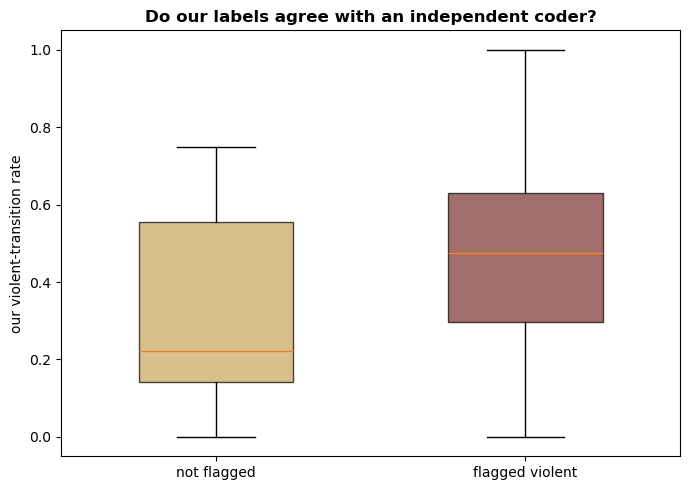

In [4]:
fig, ax = plt.subplots(figsize=(7,5))
data = [unflag.values, flagged.values]
bp = ax.boxplot(data, labels=['not flagged','flagged violent'], patch_artist=True, widths=0.5)
for patch, col in zip(bp['boxes'], ['#c9a55c','#7a2f2f']): patch.set_facecolor(col); patch.set_alpha(0.7)
ax.set_ylabel('our violent-transition rate'); ax.set_title('Do our labels agree with an independent coder?', fontweight='bold')
import os; os.makedirs('figures', exist_ok=True)
plt.tight_layout(); plt.savefig('figures/14_label_validation.png', dpi=150, bbox_inches='tight'); plt.show()


## 3. Reading the result honestly

Interpret the printed numbers directly (they are computed above, not asserted here). Whatever the direction:
- If flagged polities have a clearly higher violent-transition rate → our labels track an independently-coded signal, and the contagion result is not an artifact of one coding team.
- If the gap is small or the test is non-significant → with n≈47 that is *expected*, and the honest statement is that this validation is under-powered, not that the labels are wrong.

**What this does NOT show:** the two coders are not fully independent (both descend from the Seshat/CrisisDB effort and its expert pool — Slingerland et al. 2020, *Coding culture*, [Evol. Hum. Sci. 2:e29](https://doi.org/10.1017/ehs.2020.30)), and name-matching drops the majority of cases. A stronger validation would fuzzy-match names and hand-audit disagreements — deferred, and flagged as future work rather than claimed.

---
### References
- Hoyer, Bennett, Reddish, Turchin et al. 2023. *Navigating polycrisis.* Phil. Trans. R. Soc. B 378:20220402.
- Hoyer, Reddish, François, Turchin et al. 2024. *All Crises are Unhappy in Their Own Way.* Social Science History. [doi:10.31235/osf.io/rk4gd](https://doi.org/10.31235/osf.io/rk4gd)
- Slingerland et al. 2020. *Coding culture.* Evol. Hum. Sci. 2:e29. [doi:10.1017/ehs.2020.30](https://doi.org/10.1017/ehs.2020.30)
